In [ ]:
# Instalando pacotes necessários para análise
install.packages("fitdistrplus")
install.packages("knitr")
install.packages("lmtest")
install.packages("FNN")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘zoo’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



A

In [ ]:
# Carregando bibliotecas
library(tidyr)
library(dplyr)
library(fitdistrplus)
library(ggplot2)
library(knitr)
library(lmtest)
library(FNN)
library(class)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: MASS


Attaching package: ‘MASS’


The following object is masked from ‘package:dplyr’:

    select


Loading required package: survival

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric



Attaching package: ‘class’


The following objects are masked from ‘package:FNN’:

    knn, knn.cv




In [ ]:
# Carregando a base de dados
df <- read.csv("criminalidade_baixada_santista.csv")

In [ ]:
# Calculando a média anual e plotando gráfico de linha
df %>%
  group_by(ANO) %>%
  summarise(MEDIA = round(mean(TOTAL_CRIME, na.rm = TRUE))) %>%
  ggplot(aes(x = ANO, y = MEDIA)) +
  geom_line() +
  geom_point() +
  labs(
    title = "Média de Crimes por Ano",
    x = "Ano",
    y = "Média de Roubos"
  ) +
  theme_minimal()

In [ ]:
# Calculando a mediana anual de crimes
df %>% group_by(ANO) %>% summarise(MEDIANA = median(TOTAL_CRIME, na.rm = TRUE))

In [ ]:
# Calculando a moda anual de crimes
df %>%
  group_by(ANO) %>%
  summarise(
    MODA = as.numeric(
      names(which.max(table(TOTAL_CRIME)))
    )
  )

In [ ]:
# Calculando desvio em relação à média anual
df %>% group_by(ANO) %>% reframe(DESVIO = TOTAL_CRIME - mean(TOTAL_CRIME, na.rm = TRUE))

In [ ]:
# Calculando desvio padrão anual
df %>% group_by(ANO) %>% summarise(DESVIO_PADRAO = sd(TOTAL_CRIME))

In [ ]:
# Calculando variância anual
df %>% group_by(ANO) %>% summarise(VARIANCIA = var(TOTAL_CRIME))

In [ ]:
# Calculando desvio absoluto médio anual
df %>% group_by(ANO) %>% summarise(DESVIO_ABS_MEDIO = mean(abs(TOTAL_CRIME - mean(TOTAL_CRIME))))

In [ ]:
# Calculando MAD (desvio absoluto mediano) anual
df %>% group_by(ANO) %>% summarise(MAD = mad(TOTAL_CRIME))

In [ ]:
# Calculando amplitude anual
df %>% group_by(ANO) %>% summarise(AMPLITUDE = diff(range(TOTAL_CRIME)))

In [ ]:
# Calculando quantil (90%) anual
df %>% group_by(ANO) %>% summarise(QUANTIL = quantile(TOTAL_CRIME, probs = 0.9))

In [ ]:
# Plotando densidade dos dados
plot(density(df$TOTAL_CRIME), main = "DENSIDADE - TOTAL DE ROUBOS", col = "blue")

In [ ]:
# Plotando boxplot dos dados
boxplot(df$TOTAL_CRIME,
main = "Box Plot - Total de Roubos",
ylab = "Valores",
col = "lightblue",
border = "darkblue",
outline = FALSE,
notch = F)

In [ ]:
# Plotando histograma dos dados
roubos <- df$TOTAL_CRIME

hist(roubos,
     col = "lightblue",
     main = "Histograma Total de Roubos",
     xlab = "Roubos")

In [ ]:
# Ajustando distribuição normal e plotando o ajuste
ajuste <- fitdist(df$TOTAL_CRIME, "norm")
plot(ajuste)

In [ ]:
# Ajustando normal e sobrepondo curva ao histograma
x <- df$TOTAL_CRIME

ajuste_norm <- fitdist(x, "norm")
hist(x, breaks = 20, probability = TRUE, col = "lightblue",
     main = "Histograma e curva normal ajustada", xlab = "x")

x_seq <- seq(min(x), max(x), length.out = 200)

lines(x_seq, dnorm(x_seq, mean = ajuste_norm$estimate["mean"],
                         sd   = ajuste_norm$estimate["sd"]),
      col = "red", lwd = 2)

In [ ]:
x <- df$ROUBO_VEICULO
ajuste_exp <- fitdist(x, "exp")

hist(x, breaks = 20, probability = TRUE, col = "lightblue",
     main = "Histograma e curva exponencial ajustada", xlab = "x")

x_seq <- seq(min(x), max(x), length.out = 200)

lines(x_seq, dexp(x_seq, rate = ajuste_exp$estimate["rate"]),
      col = "red", lwd = 2)

In [ ]:
# Selecionando variáveis, calculando matriz de correlação
vars <- df %>%
  dplyr::select(
    FURTO_OUTROS,
    FURTO_VEICULO,
    HOMICIDIO_CULPOSO_ACIDENTE_TRANSITO,
    HOMICIDIO_CULPOSO_OUTROS,
    HOMICIDIO_DOLOSO,
    LATROCINIO,
    LESAO_CORPORAL_ACIDENTE_TRANSITO,
    LESAO_CORPORAL_CULPOSA_OUTRAS,
    LESAO_CORPORAL_DOLOSA,
    ROUBO_BANCO,
    ROUBO_CARGA,
    ROUBO_OUTROS,
    ROUBO_VEICULO,
    TENTATIVA_HOMICIDIO
  )
cor_mat <- cor(vars, use = "complete.obs")

# Transformando em data frame
cor_df <- as.data.frame(as.table(cor_mat))

# Removendo correlação = 1
cor_df <- cor_df[cor_df$Freq != 1, ]

# Removendos duplicados (A-B e B-A)
cor_df <- cor_df[as.character(cor_df$Var1) < as.character(cor_df$Var2), ]

# Ordenando correlação
cor_df <- cor_df[order(-cor_df$Freq), ]

cor_df

In [ ]:
# Definindo target e preditora
x <- df$FURTO_OUTROS
y <- df$LESAO_CORPORAL_DOLOSA

# Calculando o modelo linear
modelo = lm(
  formula = x ~ y,
  data = df,
  subset = x > 0,
  weights = 1/x,
  na.action = na.omit
)

# Mostrando os coeficientes
coef(modelo)

# Gerando o gráfico
plot(y, x , pch = 19, col = "darkgray", xlab = "x", ylab = "y")
abline(modelo, col = "blue", lwd = 2)

In [ ]:
df_lag <- df %>%
  arrange(df) %>%
  mutate(furto_lag1 = lag(FURTO_OUTROS, 1),
         furto_lag2 = lag(FURTO_OUTROS, 2))

cor(df_lag$furto_lag1, df$LESAO_CORPORAL_DOLOSA, use = "complete.obs")

In [ ]:
grangertest(LESAO_CORPORAL_DOLOSA ~ FURTO_OUTROS, order = 2, data = df)

In [ ]:
ts_furto <- ts(df$FURTO_OUTROS)
ts_lesao <- ts(df$LESAO_CORPORAL_DOLOSA)

ccf(ts_furto, ts_lesao, main = "Furto e Lesão Corporal")

In [ ]:
library(dplyr)

df %>%
  group_by(MUNICIPIO) %>%
  summarise(correlacao = cor(FURTO_OUTROS, LESAO_CORPORAL_DOLOSA, use = "complete.obs"))

In [ ]:
dados <- df[, c("FURTO_OUTROS", "LESAO_CORPORAL_DOLOSA")]

kmeans_result <- kmeans(dados, centers = 3)

plot(kmeans_result$cluster)

In [ ]:
# Treino e teste do modelo (80|20)

n <- nrow(df)
train_index <- sample(1:n, size = 0.8 * n)

train <- df[train_index, ]
test  <- df[-train_index, ]

knn_pred <- knn(
  train = train[, 5:7],
  test  = test[, 5:7],
  cl    = train[, 17],
  k     = 5
)

data.frame(knn_pred)

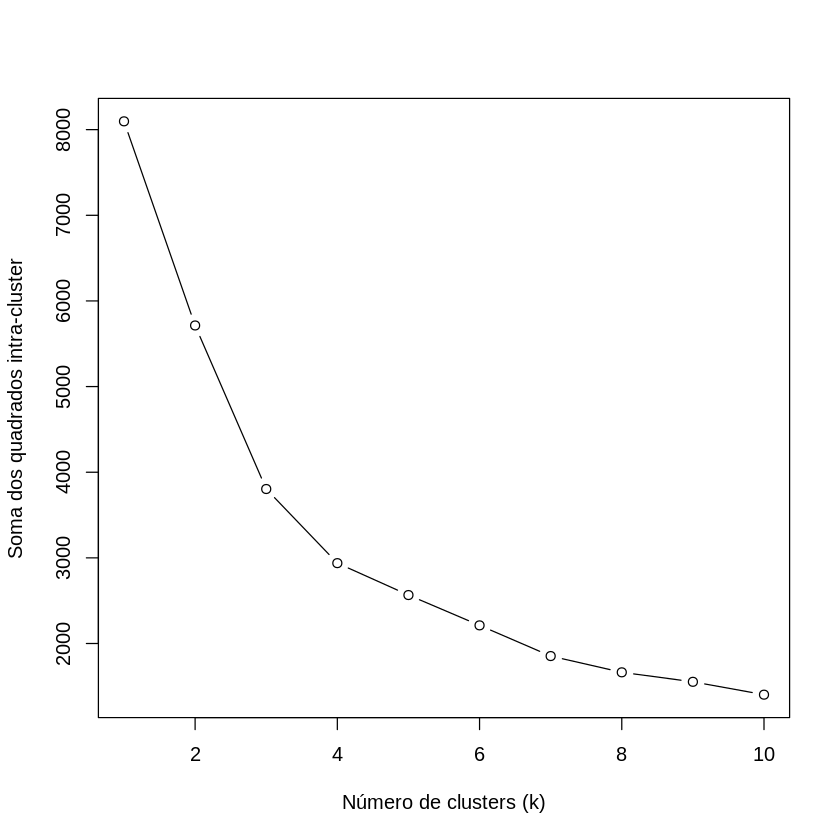

In [ ]:
dados <- scale(df[, 5:7])

wss <- sapply(1:10, function(k){
  kmeans(dados, centers = k, nstart = 10)$tot.withinss
})

plot(1:10, wss, type = "b",
     xlab = "Número de clusters (k)",
     ylab = "Soma dos quadrados intra-cluster")

kmeans_model <- kmeans(dados, centers = 2, nstart = 25)

df$cluster <- as.factor(kmeans_model$cluster)